# Data Cleaning with Pandas and Visualizations
This notebook demonstrates five common data cleaning techniques using pandas, with generated data and visualizations.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Explanation**
- `import pandas as pd`: Loads the pandas library, which is essential for data manipulation and analysis in Python.
- `import numpy as np`: Loads numpy, a library for efficient numerical operations and random data generation.
- `import matplotlib.pyplot as plt`: Loads matplotlib's plotting module, used for creating visualizations to better understand and communicate data cleaning steps.

## 1. Handling Missing Values

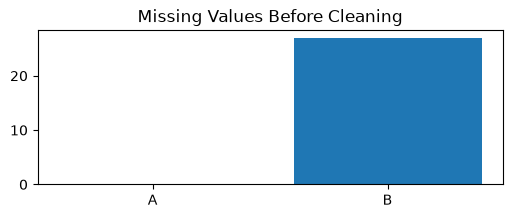

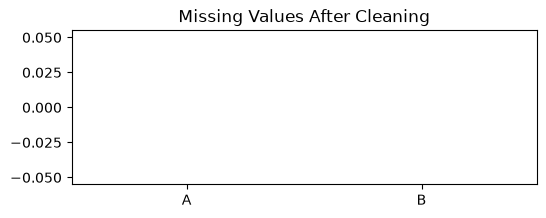

In [ ]:
# Generate data with missing values
df = pd.DataFrame({
    'A': np.random.randn(100),
    'B': np.random.choice([np.nan, 1, 2, 3], size=100)
})

# Visualize missing values
plt.figure(figsize=(6,2))
plt.title("Missing Values Before Cleaning")
plt.bar(['A', 'B'], [df['A'].isna().sum(), df['B'].isna().sum()])
plt.show()

# Fill missing values
df['B'] = df['B'].fillna(df['B'].mean())

# Visualize after cleaning
plt.figure(figsize=(6,2))
plt.title("Missing Values After Cleaning")
plt.bar(['A', 'B'], [df['A'].isna().sum(), df['B'].isna().sum()])
plt.show()

**Explanation**
- Generates a DataFrame with random values and introduces missing values (`np.nan`) in column 'B' to simulate real-world data issues.
- Uses `plt.bar` to visualize the number of missing values in each column before cleaning, helping identify which columns need attention.
- Fills missing values in column 'B' with the mean of the non-missing values using `fillna(df['B'].mean())`, a common imputation technique.
- Visualizes the columns again after cleaning to confirm that missing values have been handled, ensuring the dataset is ready for analysis.

## 2. Removing Duplicates

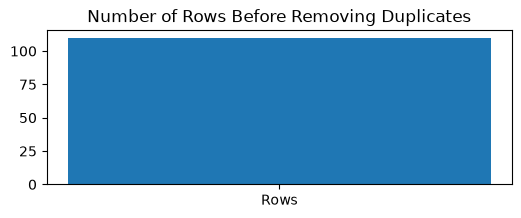

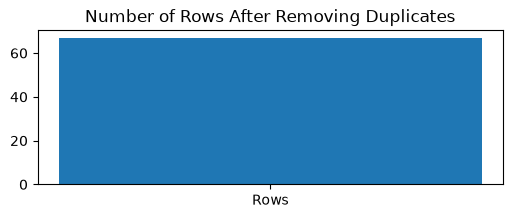

In [ ]:
# Generate data with duplicates
df = pd.DataFrame({
    'A': np.random.randint(0, 10, 100),
    'B': np.random.randint(0, 10, 100)
})
df = pd.concat([df, df.iloc[:10]], ignore_index=True)  # Add duplicates

# Visualize duplicates
plt.figure(figsize=(6,2))
plt.title("Number of Rows Before Removing Duplicates")
plt.bar(['Rows'], [len(df)])  
plt.show()

# Remove duplicates
df_clean = df.drop_duplicates()

plt.figure(figsize=(6,2))
plt.title("Number of Rows After Removing Duplicates")
plt.bar(['Rows'], [len(df_clean)])
plt.show()

**Explanation**
- Creates a DataFrame with random integer values and deliberately adds duplicate rows to mimic common data entry errors.
- Visualizes the total number of rows before cleaning to show the effect of duplicates on dataset size.
- Uses `drop_duplicates()` to remove repeated rows, ensuring each record is unique and improving data quality.
- Visualizes the row count after cleaning to demonstrate the reduction in duplicates and confirm the cleaning step was successful.

## 3. Converting Data Types

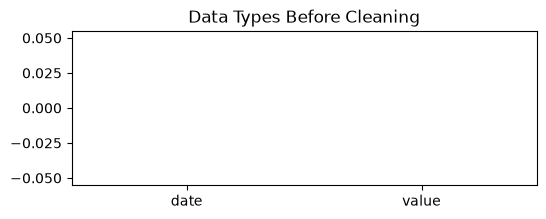

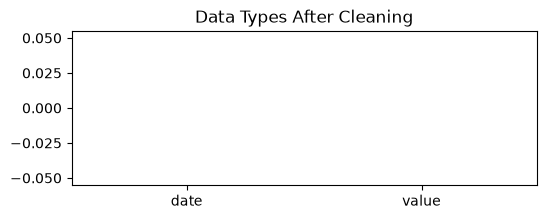

In [5]:
# Generate data with wrong types
df = pd.DataFrame({
    'date': ['2025-08-26', '2025-08-27', '2025-08-28', 'not_a_date'],
    'value': ['1', '2', 'three', '4']
})

# Before conversion
plt.figure(figsize=(6,2))
plt.title("Data Types Before Cleaning")
plt.bar(df.columns, [df[col].dtype == 'object' for col in df.columns])
plt.show()

# Convert types
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['value'] = pd.to_numeric(df['value'], errors='coerce')

# After conversion
plt.figure(figsize=(6,2))
plt.title("Data Types After Cleaning")
plt.bar(df.columns, [df[col].dtype == 'object' for col in df.columns])
plt.show()

**Explanation**
- Generates a DataFrame with columns containing string representations of dates and numbers, including some invalid entries to simulate messy data.
- Visualizes the data types before cleaning to highlight columns that need conversion for proper analysis.
- Converts the 'date' column to datetime format and the 'value' column to numeric, using error coercion to handle invalid entries gracefully.
- Visualizes the data types after cleaning to confirm successful conversion, which is essential for accurate computations and time-based analysis.

## 4. Handling Outliers

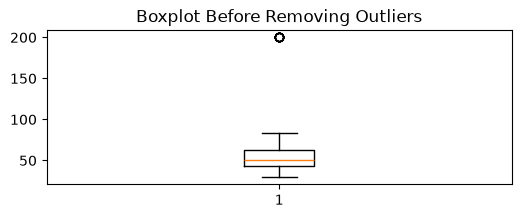

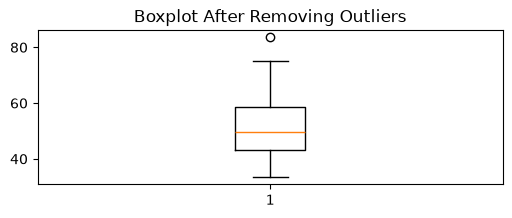

In [6]:
# Generate data with outliers
data = np.random.normal(50, 10, 100)
data[::10] = 200  # Add outliers
df = pd.DataFrame({'value': data})

# Visualize before cleaning
plt.figure(figsize=(6,2))
plt.title("Boxplot Before Removing Outliers")
plt.boxplot(df['value'])
plt.show()

# Remove outliers
q_low = df['value'].quantile(0.01)
q_high = df['value'].quantile(0.99)
df_clean = df[(df['value'] > q_low) & (df['value'] < q_high)]

# Visualize after cleaning
plt.figure(figsize=(6,2))
plt.title("Boxplot After Removing Outliers")
plt.boxplot(df_clean['value'])
plt.show()

**Explanation**
- Generates a dataset with normally distributed values and injects extreme outliers to simulate real-world measurement errors or anomalies.
- Visualizes the data distribution with a boxplot before cleaning, making it easy to spot outliers.
- Removes outliers by filtering values outside the 1st and 99th percentiles, a robust method to retain most data while excluding extreme values.
- Visualizes the cleaned data with another boxplot to confirm that outliers have been removed, resulting in a more reliable dataset for analysis.

## 5. Standardizing Text Data

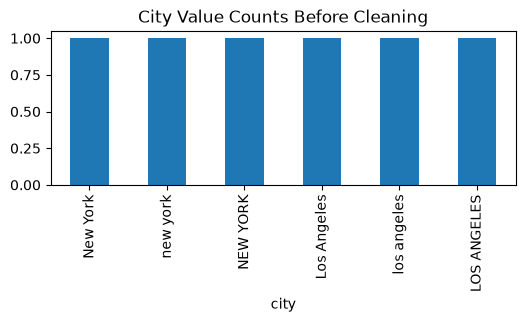

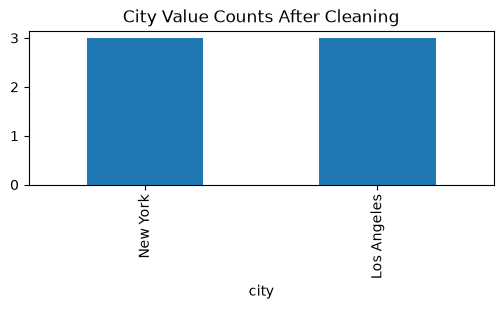

In [7]:
# Generate messy text data
df = pd.DataFrame({
    'city': ['New York', 'new york', 'NEW YORK', 'Los Angeles', 'los angeles', 'LOS ANGELES']
})

# Before cleaning
plt.figure(figsize=(6,2))
plt.title("City Value Counts Before Cleaning")
df['city'].value_counts().plot(kind='bar')
plt.show()

# Standardize text
df['city'] = df['city'].str.lower().str.strip().str.title()

# After cleaning
plt.figure(figsize=(6,2))
plt.title("City Value Counts After Cleaning")
df['city'].value_counts().plot(kind='bar')
plt.show()

**Explanation**
- Creates a DataFrame with city names in various cases and formats to mimic inconsistent data entry.
- Visualizes the frequency of each city name before cleaning, showing how inconsistent formatting can fragment your data.
- Standardizes the city names by converting them to lowercase, stripping whitespace, and applying title case, ensuring consistency for grouping and analysis.
- Visualizes the value counts after cleaning to demonstrate the effectiveness of standardization, making the data ready for reliable aggregation and reporting.